2026-04-14 14:59:47.749883: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Setting up Sionna scene...
2026-04-14 14:59:51 WARN  [HDRFilm] Monochrome mode enabled, setting film output pixel format to 'luminance' (was rgb).
Grid: 210m x 320m with 3m resolution
Total test points: 7700
Place sensor at [0.0, 0.0, 10.0]
Created 7700 receiver positions
Running ray tracing simulation...
Computing paths (this may take a moment)...
Simulation complete!
Paths.a type: <class 'tuple'>
Real part shape: (7700, 1, 1, 1, 11)
Imag part shape: (7700, 1, 1, 1, 11)
RSS linear shape: (7700,)
RSS 2D shape: (110, 70)
RSS range: -180.00 to -40.07 dBm
Coverage: 7240 / 7700 cells covered


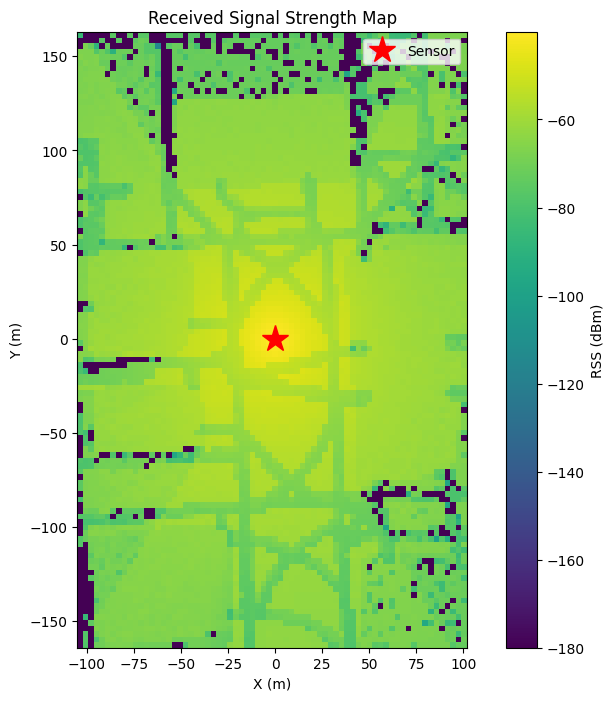

Saved coverage_map.png


In [1]:
import sionna
from sionna.rt import load_scene, Transmitter, Receiver, PlanarArray, Camera, PlanarRadioMap, PathSolver
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("Setting up Sionna scene...")

# Load a simple scene (flat ground, no obstacles)
scene = load_scene("simple_scene/NOTRE_DAME_2_563481.0550282092_4616582.2273852/simple_OSM_scene.xml")

# Define coverage area
grid_size_x = 210 
grid_size_y = 320
resolution = 3 # 5m resolution (start coarse, refine later) --> testing with 3m
# np.arange creates array of evenly spaced values within a defined interval
x = np.arange(-105, 105, resolution)
y = np.arange(-164, 164, resolution)
# np.meshgrid creates rectangular grid from set of 1D coordinate arrays 
X, Y = np.meshgrid(x, y)
# np.stack joins a sequence of arrays along a new axis 
grid_points = np.stack([X.flatten(), Y.flatten(), np.zeros(X.size)], axis=1) # z=0

print(f"Grid: {grid_size_x}m x {grid_size_y}m with {resolution}m resolution")
print(f"Total test points: {len(grid_points)}")

# Create antenna (isotropic for simplicity)
array = PlanarArray(
    num_rows=1,
    num_cols=1,
    vertical_spacing=0.5,
    horizontal_spacing=0.5,
    pattern="iso", # isotropic (radiates equally in all directions)
    polarization="V"
)

# Place sensor (aka transmitter) at center
sensor_pos = [0.0, 0.0, 10.0] # x, y, z (10m height)
tx = Transmitter(
    name="sensor",
    position=sensor_pos,
    orientation=[0,0,0]
)
tx.array = array
scene.add(tx)

print(f"Place sensor at {sensor_pos}")

# Create receivers at all grid points
receivers = []
for i, pos in enumerate(grid_points):
    rx = Receiver(
        name=f"emitter_{i}",
        position=pos.tolist(),
        orientation=[0,0,0]
    )
    rx.array = array
    scene.add(rx)
    receivers.append(rx)

print(f"Created {len(receivers)} receiver positions")

# Set frequency and bandwidth
scene.frequency = 2.4e9 # 2.4 GHz
scene.synthetic_array = False # Use actual antenna array

# Set scene-level arrays
scene.tx_array = array # Set transmitter array for the scene
scene.rx_array = array # Set receiver array for the scene

#scene.preview()
#print("Saved to scene_view.png")

print("Running ray tracing simulation...")

# Create path solver
paths_solver = PathSolver()

# Compute paths between transmitter and all receivers
print("Computing paths (this may take a moment)...")
paths = paths_solver(scene, max_depth=4, samples_per_src=int(1e6))

print("Simulation complete!")
print(f"Paths.a type: {type(paths.a)}")

# paths.a is a tuple of (real, imaginary) parts
h_real = paths.a[0]  # Real part
h_imag = paths.a[1]  # Imaginary part

print(f"Real part shape: {h_real.shape}")
print(f"Imag part shape: {h_imag.shape}")

# Compute magnitude of complex channel coefficients
# |h|^2 = real^2 + imag^2
path_power = h_real**2 + h_imag**2

# Sum power over paths (axis 3) and time steps (axis 4)
# Shape is [num_rx=400, num_tx=1, 1, max_num_paths=1, num_time_steps=22]
total_power = np.sum(path_power, axis=(3, 4))  # Sum over paths and time

# Shape is now [400, 1, 1]
rss_linear = total_power[:, 0, 0]  # Extract all 400 receivers

print(f"RSS linear shape: {rss_linear.shape}")  # Should be (400,)

# Convert to dBm
tx_power_dbm = 20  # 20 dBm transmit power
rss_dbm = 10 * np.log10(rss_linear + 1e-20) + tx_power_dbm

# Reshape back to 2D grid (20x20 = 400)
rss_2d = rss_dbm.reshape(len(y), len(x))

print(f"RSS 2D shape: {rss_2d.shape}")
print(f"RSS range: {np.nanmin(rss_dbm):.2f} to {np.nanmax(rss_dbm):.2f} dBm")

# Create binary coverage map (threshold at -90 dBm)
threshold_dbm = -90
coverage = (rss_2d > threshold_dbm).astype(int)

print(f"Coverage: {np.sum(coverage)} / {coverage.size} cells covered")

# Visualize
plt.figure(figsize=(10, 8))
plt.imshow(rss_2d, extent=[x.min(), x.max(), y.min(), y.max()], origin='lower', cmap='viridis')
plt.colorbar(label='RSS (dBm)')
plt.plot(sensor_pos[0], sensor_pos[1], 'r*', markersize=20, label='Sensor')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('Received Signal Strength Map')
plt.legend()
plt.savefig('coverage_map.png')
plt.show()
print("Saved coverage_map.png")